# BÁO CÁO PHẦN 2: TIỀN XỬ LÝ DỮ LIỆU BẢNG (TABULAR DATA PREPROCESSING)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


## About dataset

### Customer Transactions Dataset

Bộ dữ liệu này chứa các thông tin giao dịch của khách hàng, phản ánh mô hình chi tiêu, thu nhập, độ tuổi và hành vi mua sắm. Dữ liệu chưa được làm sạch hoàn toàn và có một số vấn đề cần xử lý.

#### Các đặc trưng (Features)

- **Customer_ID**: Mã định danh của khách hàng, có thể xuất hiện trùng lặp 
- **Age**: Độ tuổi của khách hàng, dữ liệu có thể bị thiếu và tồn tại ngoại lệ 
- **Annual_Income**: Thu nhập hàng năm của khách hàng, phân phối dữ liệu bị lệch 
- **Spending_Score**: Điểm chi tiêu của khách hàng, chưa được chuẩn hóa 
- **Purchase_Frequency**: Tần suất mua hàng của khách hàng, có thể xuất hiện giá trị cực đoan 
- **Transaction_Amount**: Giá trị giao dịch của khách hàng, dữ liệu có nhiễu và một số giá trị bị thiếu



In [2]:
df = pd.read_csv("../data/tabular//unclean_customer_data.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         10200 non-null  int64  
 1   Age                 9943 non-null   float64
 2   Annual_Income       10200 non-null  float64
 3   Spending_Score      10200 non-null  float64
 4   Purchase_Frequency  10200 non-null  int64  
 5   Transaction_Amount  9944 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 478.3 KB


In [3]:
# Checking the Size
print(f"\nShape of DataSet: {df.shape}")


Shape of DataSet: (10200, 6)


In [4]:
# Checking for Duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"\n--- Duplicate Rows: {duplicates} ---")
    df = df.drop_duplicates()
    print(f"New Shape of Training Data: {df.shape}")


--- Duplicate Rows: 200 ---
New Shape of Training Data: (10000, 6)


## A. Handling Missing Values

### A.1. Identify Missing Values Pattern

In [5]:
# A.1. Identify Missing Values
print("=== A. HANDLING MISSING VALUES ===\n")
print("1. Missing Values Summary:")
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {missing_summary.sum()}")
print(f"Total rows with missing values: {df.isnull().any(axis=1).sum()}")



=== A. HANDLING MISSING VALUES ===

1. Missing Values Summary:
                    Missing Count  Missing Percentage
Age                           250                 2.5
Transaction_Amount            250                 2.5

Total missing values: 500
Total rows with missing values: 500


### A.2. Analyze Missing Data Pattern (MCAR, MAR, MNAR)

**Phân tích pattern của missing data:**

Để xác định pattern của missing data, chúng ta cần kiểm tra:
1. **MCAR (Missing Completely At Random)**: Dữ liệu thiếu hoàn toàn ngẫu nhiên
2. **MAR (Missing At Random)**: Dữ liệu thiếu phụ thuộc vào các biến quan sát được
3. **MNAR (Missing Not At Random)**: Dữ liệu thiếu phụ thuộc vào chính giá trị thiếu đó 

In [6]:
# A.2. Analyze Missing Data Pattern
print("\n2. Analyzing Missing Data Pattern:")

# Check if missing values are correlated with other variables
print("\n--- Correlation between missing indicators and other variables ---")
df_with_missing_flag = df.copy()
df_with_missing_flag['Age_Missing'] = df['Age'].isnull().astype(int)
df_with_missing_flag['Transaction_Amount_Missing'] = df['Transaction_Amount'].isnull().astype(int)

# Check correlation
if 'Age_Missing' in df_with_missing_flag.columns:
    corr_age = df_with_missing_flag[['Age_Missing', 'Annual_Income', 'Spending_Score', 
                                      'Purchase_Frequency', 'Transaction_Amount']].corr()
    print("\nCorrelation of Age_Missing with other variables:")
    print(corr_age['Age_Missing'].sort_values(ascending=False))

if 'Transaction_Amount_Missing' in df_with_missing_flag.columns:
    corr_ta = df_with_missing_flag[['Transaction_Amount_Missing', 'Age', 'Annual_Income', 
                                     'Spending_Score', 'Purchase_Frequency']].corr()
    print("\nCorrelation of Transaction_Amount_Missing with other variables:")
    print(corr_ta['Transaction_Amount_Missing'].sort_values(ascending=False))

# Statistical test for MCAR
print("\n--- Statistical Analysis ---")
print("Testing if missing pattern is random (MCAR)...")
age_missing_indices = df[df['Age'].isnull()].index
ta_missing_indices = df[df['Transaction_Amount'].isnull()].index

print(f"Age missing: {len(age_missing_indices)} values")
print(f"Transaction_Amount missing: {len(ta_missing_indices)} values")
print(f"Overlap (both missing): {len(set(age_missing_indices) & set(ta_missing_indices))} values")


2. Analyzing Missing Data Pattern:

--- Correlation between missing indicators and other variables ---

Correlation of Age_Missing with other variables:
Age_Missing           1.000000
Purchase_Frequency    0.009215
Transaction_Amount   -0.002630
Spending_Score       -0.015083
Annual_Income        -0.015284
Name: Age_Missing, dtype: float64

Correlation of Transaction_Amount_Missing with other variables:
Transaction_Amount_Missing    1.000000
Annual_Income                 0.019067
Age                           0.014022
Purchase_Frequency           -0.000617
Spending_Score               -0.014888
Name: Transaction_Amount_Missing, dtype: float64

--- Statistical Analysis ---
Testing if missing pattern is random (MCAR)...
Age missing: 250 values
Transaction_Amount missing: 250 values
Overlap (both missing): 0 values


Dựa trên phân tích, mô hình thiếu dữ liệu  là **MCAR (Missing Completely At Random)** vì:

1. Các giá trị thiếu được phân bố ngẫu nhiên trong toàn bộ tập dữ liệu  
2. Không có mối tương quan mạnh giữa chỉ báo dữ liệu thiếu và các biến khác  
3. Các giá trị thiếu xuất hiện độc lập với nhau  


### A.3. Apply Different Imputation Techniques

In [7]:
num_cols = ["Age", "Annual_Income", "Spending_Score", "Purchase_Frequency", "Transaction_Amount"]

#### Mean imputation

In [8]:
df_mean = df.copy()
mean_imputer = SimpleImputer(strategy="mean")
df_mean[num_cols] = mean_imputer.fit_transform(df_mean[num_cols])
print("Remaining NaNs (mean):")
print(df_mean[num_cols].isna().sum())

Remaining NaNs (mean):
Age                   0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
Transaction_Amount    0
dtype: int64


#### Median imputation

In [9]:
df_median = df.copy()
median_imputer = SimpleImputer(strategy="median")
df_median[num_cols] = median_imputer.fit_transform(df_median[num_cols])
print("\nRemaining NaNs (median):")
print(df_median[num_cols].isna().sum())



Remaining NaNs (median):
Age                   0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
Transaction_Amount    0
dtype: int64


#### KNN imputation

In [10]:
df_knn = df.copy()
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[num_cols] = knn_imputer.fit_transform(df_knn[num_cols])
print("\nRemaining NaNs (KNN):")
print(df_knn[num_cols].isna().sum())


Remaining NaNs (KNN):
Age                   0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
Transaction_Amount    0
dtype: int64


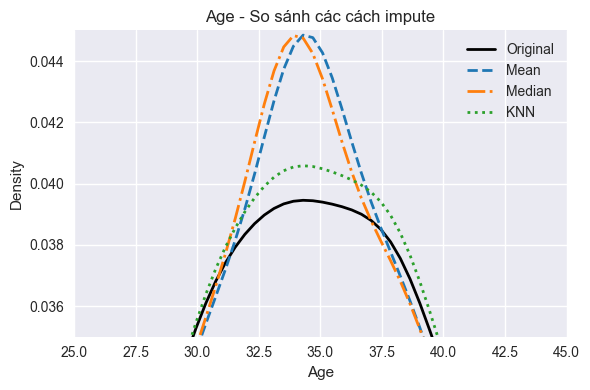

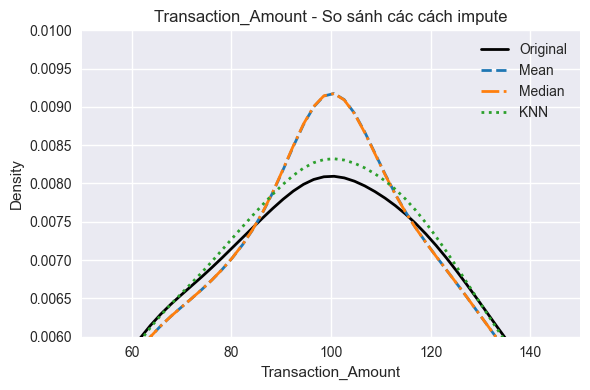

In [11]:
for col in ["Age", "Transaction_Amount"]:
    plt.figure(figsize=(6, 4))

    sns.kdeplot(df[col].dropna(),  fill=False, label="Original",
                color="black", linestyle="-",  linewidth=2)
    sns.kdeplot(df_mean[col],      fill=False, label="Mean",
                color="tab:blue",  linestyle="--", linewidth=2)
    sns.kdeplot(df_median[col],    fill=False, label="Median",
                color="tab:orange",linestyle="-.", linewidth=2)
    sns.kdeplot(df_knn[col],       fill=False, label="KNN",
                color="tab:green", linestyle=":",  linewidth=2)

    if col == "Age":
        plt.ylim(0.035, 0.045)   # ví dụ cho Age, chỉnh lại cho phù hợp
        plt.xlim(25, 45)
    elif col == "Transaction_Amount":
        plt.xlim(50, 150)
        plt.ylim(0.006, 0.01)
        
    plt.title(f"{col} - So sánh các cách impute")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

## B. Data Normalization

In [12]:
df_imputed = df_knn.copy()

features_to_scale = ["Age", "Annual_Income", "Spending_Score",
                     "Purchase_Frequency", "Transaction_Amount"]

X = df_imputed[features_to_scale]

scalers = {
    "minmax": MinMaxScaler(),
    "standard": StandardScaler(),
    "robust": RobustScaler()
}

scaled_results = {}

for name, scaler in scalers.items():
    scaled = scaler.fit_transform(X)
    scaled_results[name] = pd.DataFrame(scaled, columns=features_to_scale)


In [13]:
# --- MINMAX ---
print("\n=== MINMAX SCALING: summary statistics ===")
print(scaled_results["minmax"].describe().T)




=== MINMAX SCALING: summary statistics ===
                      count      mean       std  min       25%       50%  \
Age                 10000.0  0.499348  0.143115  0.0  0.405797  0.504348   
Annual_Income       10000.0  0.520176  0.115341  0.0  0.441809  0.520136   
Spending_Score      10000.0  0.500976  0.289191  0.0  0.253474  0.498087   
Purchase_Frequency  10000.0  0.500324  0.298786  0.0  0.241379  0.517241   
Transaction_Amount  10000.0  0.518816  0.137043  0.0  0.426599  0.518560   

                         75%  max  
Age                 0.594203  1.0  
Annual_Income       0.598983  1.0  
Spending_Score      0.753511  1.0  
Purchase_Frequency  0.758621  1.0  
Transaction_Amount  0.610123  1.0  


In [14]:
# --- STANDARD ---
print("\n=== STANDARD SCALING: summary statistics ===")
print(scaled_results["standard"].describe().T)




=== STANDARD SCALING: summary statistics ===
                      count          mean      std       min       25%  \
Age                 10000.0  1.648459e-16  1.00005 -3.489322 -0.653710   
Annual_Income       10000.0  3.694822e-16  1.00005 -4.510129 -0.679480   
Spending_Score      10000.0  1.890044e-16  1.00005 -1.732420 -0.855882   
Purchase_Frequency  10000.0  6.927792e-17  1.00005 -1.674610 -0.866701   
Transaction_Amount  10000.0 -5.115908e-17  1.00005 -3.785989 -0.672940   

                         50%       75%       max  
Age                 0.034939  0.662824  3.498436  
Annual_Income      -0.000349  0.683284  4.160253  
Spending_Score     -0.009990  0.873290  1.725672  
Purchase_Frequency  0.056623  0.864531  1.672440  
Transaction_Amount -0.001865  0.666304  3.511375  


In [15]:
# --- ROBUST ---
print("\n=== ROBUST SCALING: summary statistics ===")
print(scaled_results["robust"].describe().T)


=== ROBUST SCALING: summary statistics ===
                      count      mean       std       min       25%  \
Age                 10000.0 -0.026538  0.759608 -2.676923 -0.523077   
Annual_Income       10000.0  0.000256  0.733839 -3.309288 -0.498349   
Spending_Score      10000.0  0.005778  0.578340 -0.996101 -0.489189   
Purchase_Frequency  10000.0 -0.032707  0.577652 -1.000000 -0.533333   
Transaction_Amount  10000.0  0.001393  0.746727 -2.825567 -0.501085   

                             50%       75%       max  
Age                 0.000000e+00  0.476923  2.630769  
Annual_Income      -1.788798e-16  0.501651  3.053060  
Spending_Score      0.000000e+00  0.510811  1.003754  
Purchase_Frequency  0.000000e+00  0.466667  0.933333  
Transaction_Amount  1.075122e-16  0.498915  2.623301  


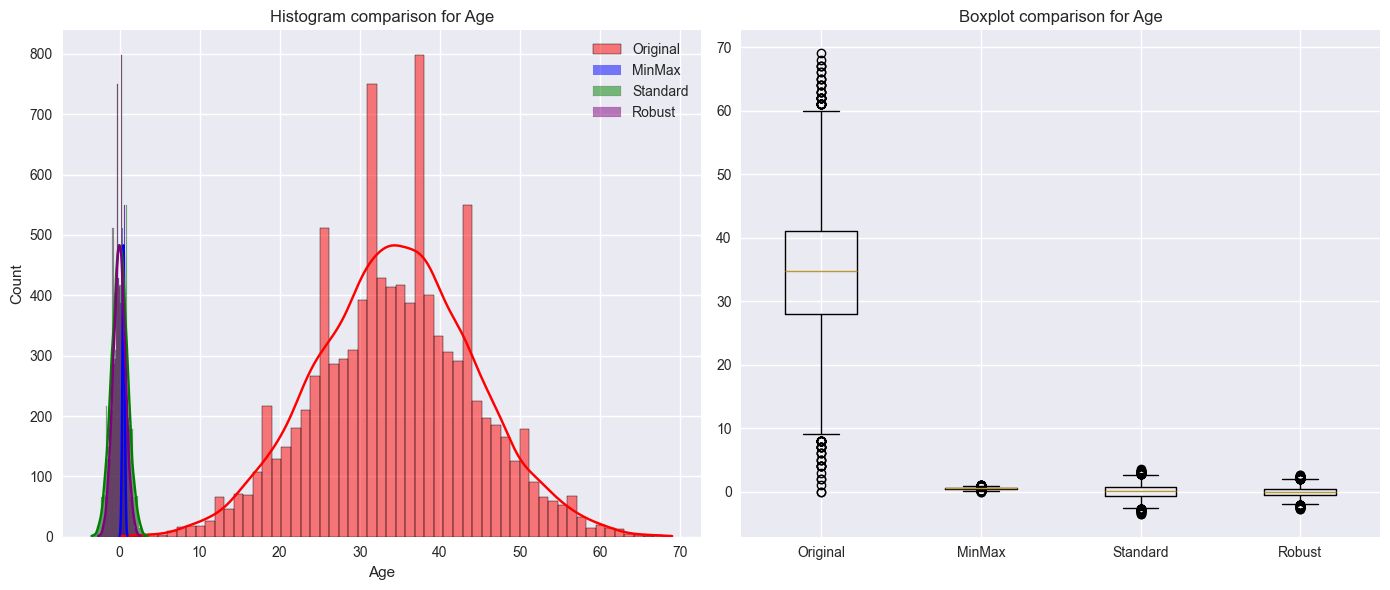

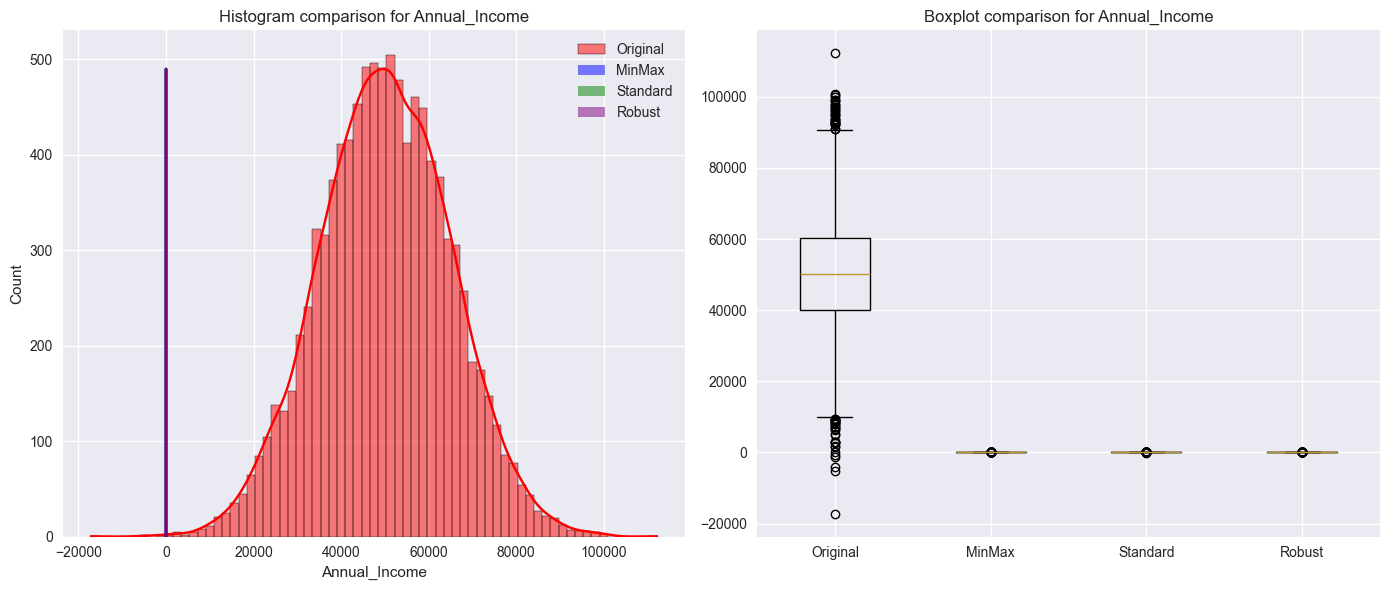

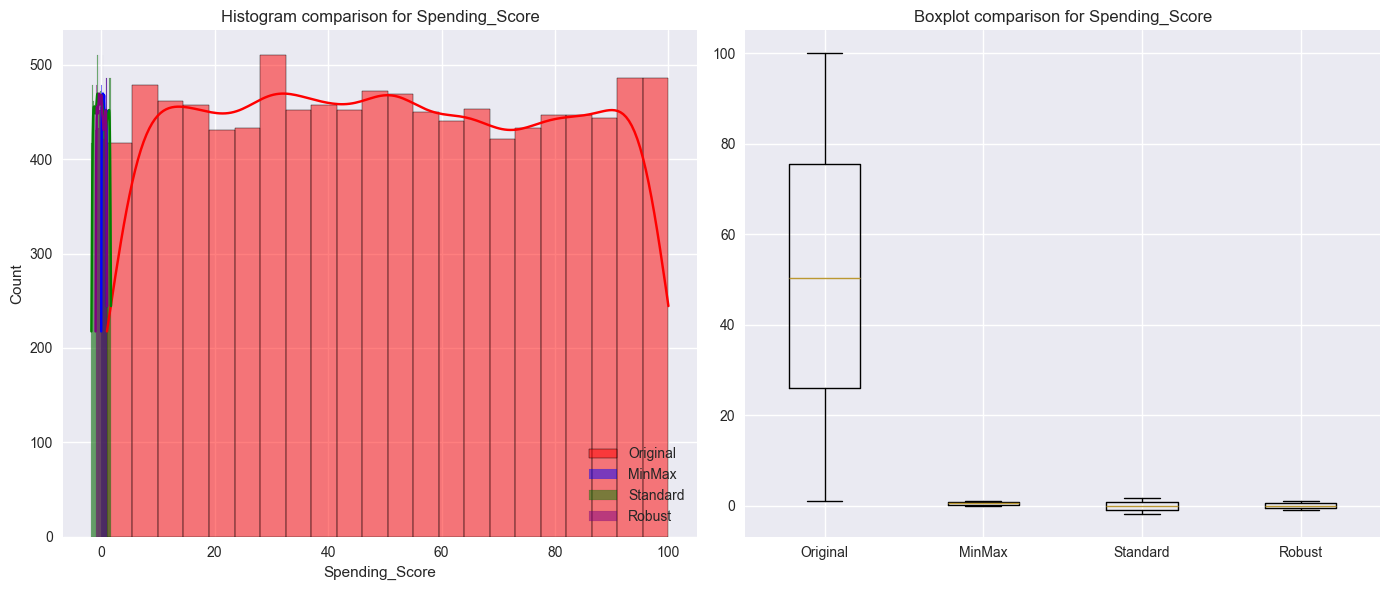

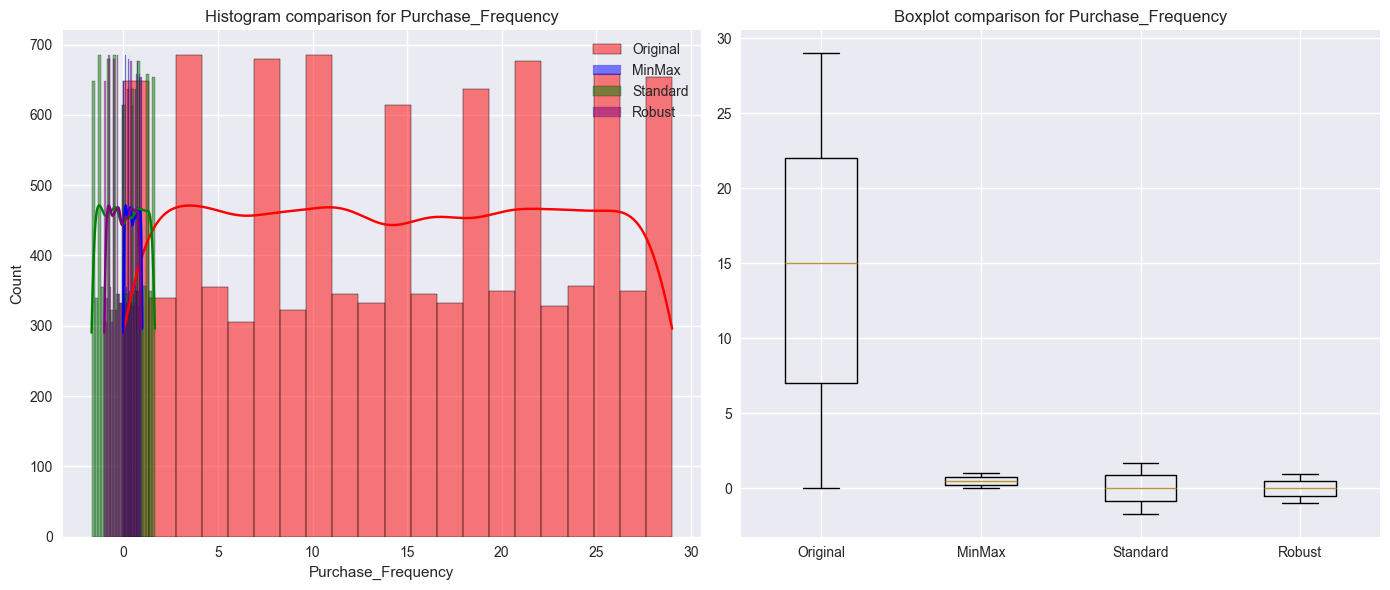

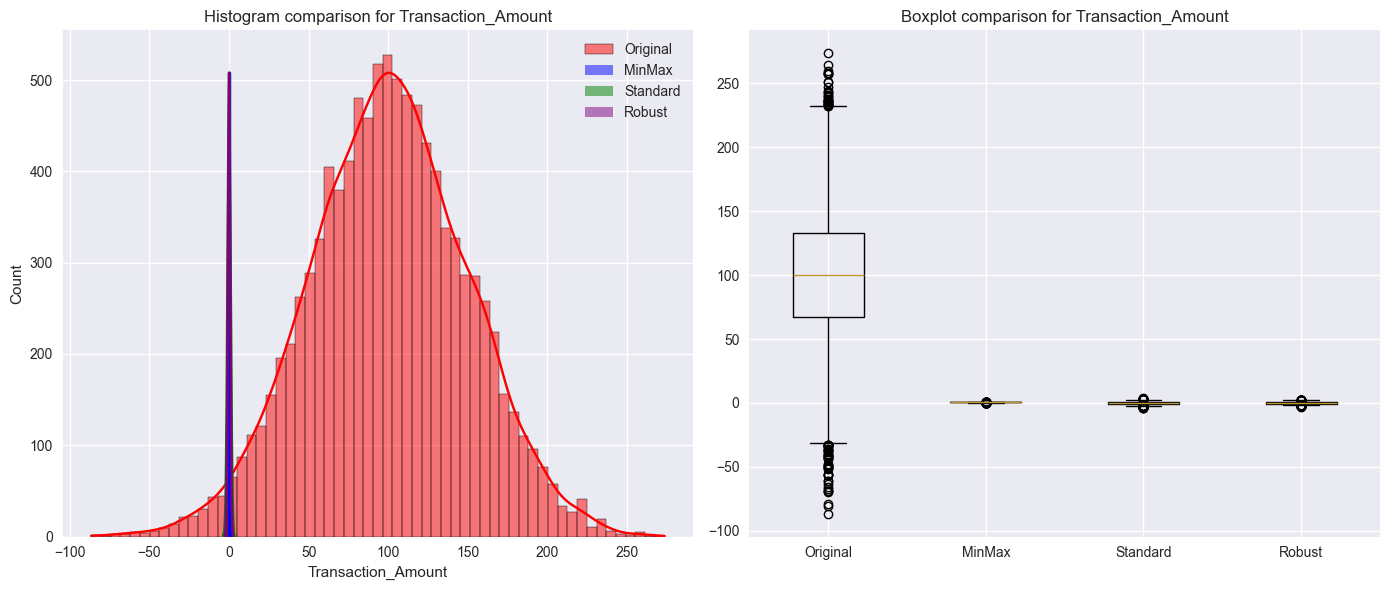

In [16]:
# Compare distributions for one feature, e.g. Age
for feature in features_to_scale:
    
    plt.figure(figsize=(14,6))

    # Histogram comparison
    plt.subplot(1,2,1)
    sns.histplot(X[feature], color="red", label="Original", kde=True)
    sns.histplot(scaled_results["minmax"][feature], color="blue", label="MinMax", kde=True)
    sns.histplot(scaled_results["standard"][feature], color="green", label="Standard", kde=True)
    sns.histplot(scaled_results["robust"][feature], color="purple", label="Robust", kde=True)
    plt.title(f"Histogram comparison for {feature}")
    plt.legend()

    # Boxplot comparison
    plt.subplot(1,2,2)
    data_to_plot = [
        X[feature],
        scaled_results["minmax"][feature],
        scaled_results["standard"][feature],
        scaled_results["robust"][feature]
    ]
    plt.boxplot(
        data_to_plot,
        tick_labels=["Original", "MinMax", "Standard", "Robust"]  # dùng tick_labels thay cho labels
    )

    plt.title(f"Boxplot comparison for {feature}")

    plt.tight_layout()
    plt.show()


## C. Categorical Encoding

In [17]:
# Create a categorical variable from Annual_Income
df_cat = df_imputed.copy()

bins = [0, 30000, 60000, np.inf]
labels = ["Low", "Medium", "High"]
df_cat["Income_Group"] = pd.cut(df_cat["Annual_Income"], bins=bins, labels=labels)

df_cat["Income_Group"].value_counts()

Income_Group
Medium    6548
High      2570
Low        877
Name: count, dtype: int64

In [18]:
# One-hot encoding for nominal categorical variable
df_onehot = pd.get_dummies(df_cat, columns=["Income_Group"], drop_first=False)
df_onehot.head()

,Customer_ID,Age,Annual_Income,Spending_Score,Purchase_Frequency,Transaction_Amount,Income_Group_Low,Income_Group_Medium,Income_Group_High
0,8270,31.0,75851.592212,77.104268,17.0,129.724190,False,False,True
1,1860,48.0,44460.183764,61.349076,25.0,91.479265,False,True,False
2,6390,17.0,43677.755605,22.589956,9.0,130.573812,False,True,False
3,6191,34.0,48666.812544,82.069525,0.0,72.395846,False,True,False
4,6734,44.0,46080.334029,65.076915,3.0,156.399077,False,True,False


In [19]:
# Ordinal encoding example (if we want to enforce an order: Low < Medium < High)
income_order = {"Low": 1, "Medium": 2, "High": 3}
df_cat["Income_Group_Ordinal"] = df_cat["Income_Group"].map(income_order)

df_cat[["Annual_Income", "Income_Group", "Income_Group_Ordinal"]].head()

,Annual_Income,Income_Group,Income_Group_Ordinal
0,75851.592212,High,3
1,44460.183764,Medium,2
2,43677.755605,Medium,2
3,48666.812544,Medium,2
4,46080.334029,Medium,2


## D. Feature Selection

### D.1. Correlation Matrix

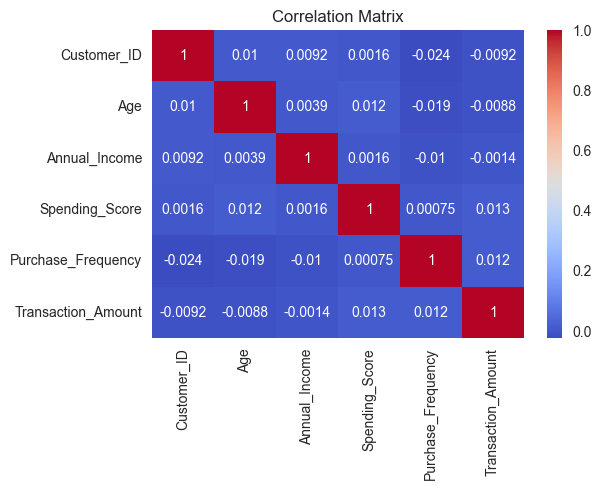

In [20]:
corr = df_imputed.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


### D.2. Variance Threshold

In [21]:
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)
selected_features_var = X.columns[selector.get_support()]
print("Selected features (Variance Threshold):", selected_features_var)


Selected features (Variance Threshold): Index(['Age', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency',
       'Transaction_Amount'],
      dtype='object')


### D.3. Feature Importance (Tree-Based Models)

Tạo biến mục tiêu: **High Spender** if Spending_Score > median, else 0

In [22]:
feature_cols = ["Age", "Annual_Income", "Purchase_Frequency", "Transaction_Amount"]
X_fs = df_imputed[feature_cols]

median_spending = df_imputed['Spending_Score'].median()
y_fs = (df_imputed['Spending_Score'] > median_spending).astype(int)

print(f"Features shape: {X_fs.shape}")
print(f"Target shape: {y_fs.shape}")
print(f"Target distribution:\n{y_fs.value_counts()}")

Features shape: (10000, 4)
Target shape: (10000,)
Target distribution:
Spending_Score
1    5000
0    5000
Name: count, dtype: int64


### D.4. Recursive Feature Elimination (RFE)

RFE with 1 features: ['Annual_Income']
RFE with 2 features: ['Annual_Income', 'Transaction_Amount']
RFE with 3 features: ['Age', 'Annual_Income', 'Transaction_Amount']
RFE with 4 features: ['Age', 'Annual_Income', 'Purchase_Frequency', 'Transaction_Amount']

 RFE Feature Ranking (lower is better):
Age                   1
Annual_Income         1
Transaction_Amount    1
Purchase_Frequency    2
dtype: int64

 Selected features (top 3): ['Age', 'Annual_Income', 'Transaction_Amount']


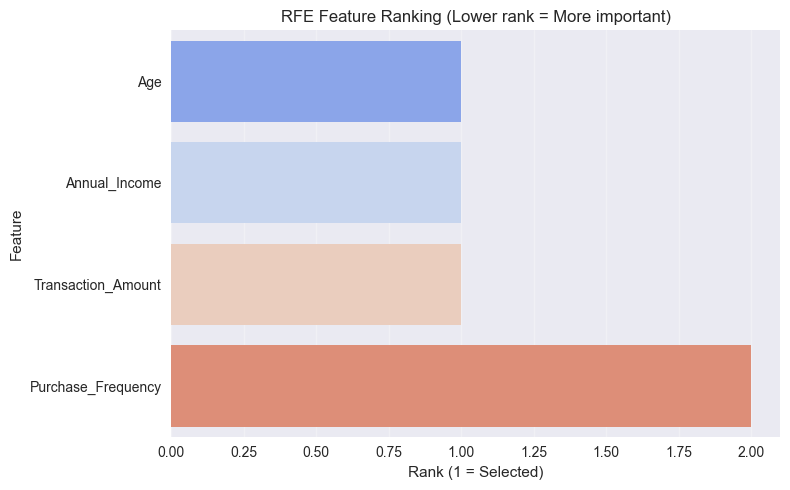

In [23]:
# Apply RFE with RandomForest
# Try different numbers of features
n_features_to_select = [1, 2, 3, 4]
rfe_results = {}

for n in n_features_to_select:
    rfe = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1), 
              n_features_to_select=n)
    rfe.fit(X_fs, y_fs)
    selected_features_rfe = X_fs.columns[rfe.support_].tolist()
    rfe_results[n] = selected_features_rfe
    print(f"RFE with {n} features: {selected_features_rfe}")

# Use RFE with 3 features (reasonable number)
rfe = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), 
          n_features_to_select=3)
rfe.fit(X_fs, y_fs)
selected_features_rfe = X_fs.columns[rfe.support_].tolist()
rfe_ranking = pd.Series(rfe.ranking_, index=feature_cols).sort_values()

print(f"\n RFE Feature Ranking (lower is better):")
print(rfe_ranking)
print(f"\n Selected features (top 3): {selected_features_rfe}")

# Visualize RFE ranking
plt.figure(figsize=(8, 5))
sns.barplot(x=rfe_ranking.values, y=rfe_ranking.index, palette='coolwarm')
plt.title("RFE Feature Ranking (Lower rank = More important)", fontsize=12)
plt.xlabel("Rank (1 = Selected)")
plt.ylabel("Feature")
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

RandomForest feature importances:
Transaction_Amount    0.320960
Annual_Income         0.319509
Age                   0.187971
Purchase_Frequency    0.171561
dtype: float64


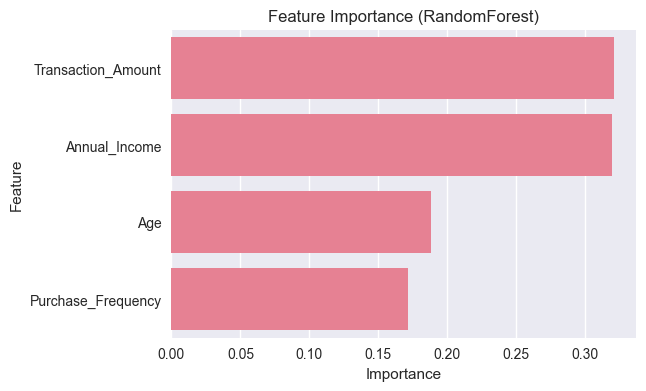

In [24]:
# 3. Feature importance from a tree-based model (RandomForest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_fs, y_fs)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("RandomForest feature importances:")
print(importances)

plt.figure(figsize=(6, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
top_k = 3
final_features = importances.head(top_k).index.tolist()
print("Final selected features:", final_features)

X_final = X_fs[final_features]



Final selected features: ['Transaction_Amount', 'Annual_Income', 'Age']
